Resumo da simulação (MEF)
N              = 64
E2/E1          = 5
u(L)           = 0.6
Erro relativo discreto = 1.667e-13
Eef (série)    = 1.666666667
--- Validação de Tensão e Deformação ---
sigma = 1
epsilon_1         = 1
epsilon_2         = 0.2


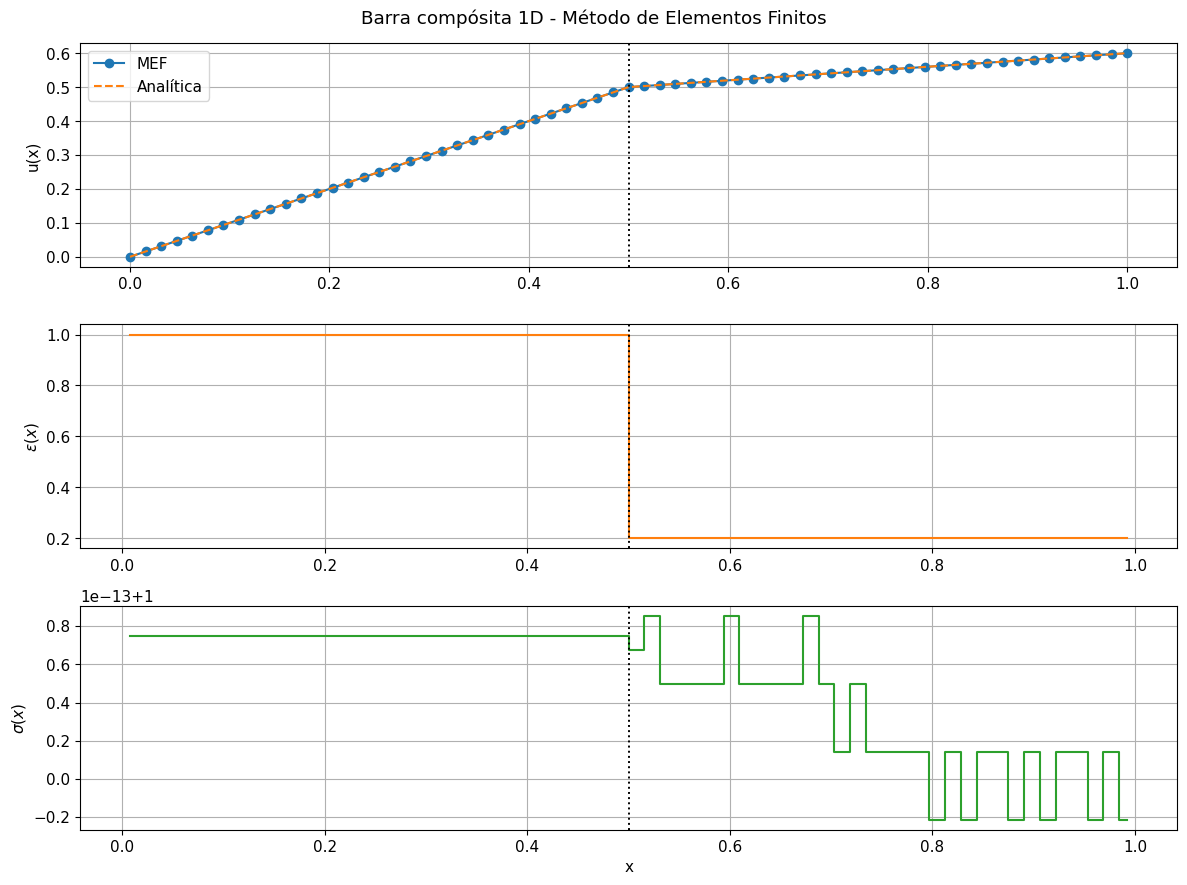

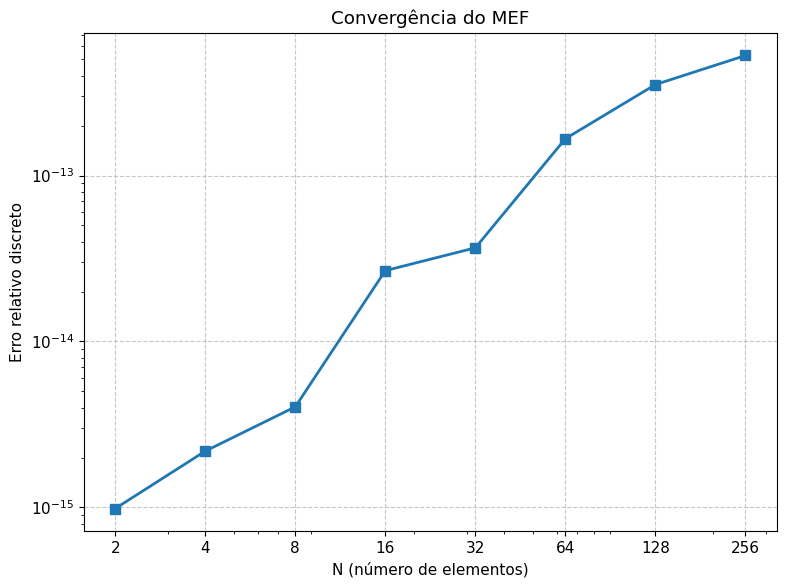

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 11

# ==========================================================
# 1. PARÂMETROS FÍSICOS E GEOMÉTRICOS
# ==========================================================
@dataclass(frozen=True)
class BarParams:
    length: float = 1.0     # L  - comprimento da barra
    area: float = 1.0       # A  - área da seção transversal
    e1: float = 1.0         # E1 - módulo de Young da metade esquerda
    e2: float = 5.0         # E2 - módulo de Young da metade direita
    traction: float = 1.0   # T  - força trativa aplicada em x = L


# ==========================================================
# 2. MÓDULO DE ELASTICIDADE E TRATAMENTO DA INTERFACE
# ==========================================================
def young_modulus(x, params):
    """E(x): E1 na metade esquerda, E2 na metade direita."""
    return np.where(x < params.length / 2.0, params.e1, params.e2)


def element_equivalent_moduli(x, params):
    """
    Módulo equivalente de cada elemento.
    Se o elemento cruza a interface (x=L/2), usa a média harmônica
    (associação em série), garantindo continuidade da tensão mesmo
    quando a malha não cai exatamente sobre a interface.
    """
    interface = params.length / 2.0
    moduli = np.empty(len(x) - 1, dtype=float)
    for i, (left, right) in enumerate(zip(x[:-1], x[1:])):
        h = right - left
        if right <= interface:
            moduli[i] = params.e1
        elif left >= interface:
            moduli[i] = params.e2
        else:
            l1 = interface - left
            l2 = right - interface
            moduli[i] = h / (l1 / params.e1 + l2 / params.e2)
    return moduli


# ==========================================================
# 3. SOLUÇÃO ANALÍTICA E ERRO RELATIVO DISCRETO
# ==========================================================
def exact_displacement(x, params):
    interface = params.length / 2.0
    eps1 = params.traction / (params.area * params.e1)
    eps2 = params.traction / (params.area * params.e2)
    u_int = eps1 * interface
    return np.where(x <= interface, eps1 * x, u_int + eps2 * (x - interface))


def relative_discrete_error(numerical, reference):
    denom = np.linalg.norm(reference)
    if denom == 0.0:
        return float(np.linalg.norm(numerical - reference))
    return float(np.linalg.norm(numerical - reference) / denom)


# ==========================================================
# 4. SOLVER DO MEF (elementos lineares 1D - Galerkin)
# ==========================================================
def solve_fem(n, params):
    if n < 2:
        raise ValueError('Use N >= 2.')

    h = params.length / n
    x = np.linspace(0.0, params.length, n + 1)
    e_nodes = young_modulus(x, params)
    e_elems = element_equivalent_moduli(x, params)     # E de cada elemento

    K = np.zeros((n + 1, n + 1), dtype=float)
    F = np.zeros(n + 1, dtype=float)

    # Montagem global via matrizes locais 2x2:  (E_e * A / h) * [[1,-1],[-1,1]]
    for e in range(n):
        k_e = e_elems[e] * params.area / h
        K[e, e]     += k_e
        K[e, e + 1] -= k_e
        K[e + 1, e] -= k_e
        K[e + 1, e + 1] += k_e

    # Condição de Neumann (natural): força T no nó da extremidade direita
    F[-1] = params.traction

    # Condição de Dirichlet: u(0) = 0  (zera a linha e fixa o grau de liberdade)
    K[0, :] = 0.0
    K[0, 0] = 1.0
    F[0] = 0.0

    u = np.linalg.solve(K, F)

    # Deformação e tensão: constantes por elemento (elemento linear)
    x_mid = 0.5 * (x[:-1] + x[1:])
    strain = np.diff(u) / h
    stress = e_elems * strain
    u_exact = exact_displacement(x, params)

    return {
        'x': x, 'u': u, 'u_exact': u_exact,
        'x_mid': x_mid, 'strain': strain, 'stress': stress,
        'e_nodes': e_nodes, 'e_elems': e_elems,
        'relative_discrete_error': relative_discrete_error(u, u_exact),
    }


def effective_modulus_series(params):
    """Módulo efetivo (associação em série) para meia-meia."""
    l = params.length / 2.0
    return params.length / (l / params.e1 + l / params.e2)


# ==========================================================
# 5. VISUALIZAÇÃO DOS CAMPOS (u, epsilon, sigma)
# ==========================================================
def plot_fields(result, params):
    fig, axes = plt.subplots(3, 1, figsize=(12, 9))
    interface = params.length / 2.0

    axes[0].plot(result['x'], result['u'], 'o-', label='MEF')
    axes[0].plot(result['x'], result['u_exact'], '--', label='Analítica')
    axes[0].set_ylabel('u(x)')
    axes[0].legend(loc='upper left')

    axes[1].step(result['x_mid'], result['strain'], where='mid', color='tab:orange')
    axes[1].set_ylabel(r'$\varepsilon(x)$')

    axes[2].step(result['x_mid'], result['stress'], where='mid', color='tab:green')
    axes[2].set_ylabel(r'$\sigma(x)$')
    axes[2].set_xlabel('x')

    for ax in axes:
        ax.axvline(interface, color='k', linestyle=':', linewidth=1.4)

    fig.suptitle('Barra compósita 1D - Método de Elementos Finitos')
    fig.tight_layout()
    plt.show()


# ==========================================================
# 6. ESTUDO DE CONVERGÊNCIA (erro relativo discreto vs N)
# ==========================================================
def plot_convergence(params, n_list=(2, 4, 8, 16, 32, 64, 128, 256)):
    # Certifique-se de usar a chave correta que alteramos anteriormente
    errors = [solve_fem(n, params)['relative_discrete_error'] for n in n_list]

    plt.figure(figsize=(8, 6))

    # Plot em escala log-log, com linha um pouco mais espessa e marcadores maiores
    plt.loglog(n_list, errors, 's-', linewidth=2, markersize=7)

    # FORÇA a exibir exatamente os valores de n_list no eixo X
    plt.xticks(n_list, [str(n) for n in n_list])

    # Textos
    plt.xlabel('N (número de elementos)')
    plt.ylabel(r'Erro relativo discreto')
    plt.title('Convergência do MEF')

    # Grid limpo: apenas linhas principais, tracejadas e com transparência
    plt.grid(True, which='major', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
    return dict(zip(n_list, errors))


# ==========================================================
# 7. EXECUÇÃO PRINCIPAL
# ==========================================================
if __name__ == '__main__':
    params = BarParams(length=1.0, area=1.0, e1=1.0, e2=5.0, traction=1.0)

    N = 64
    result = solve_fem(N, params)

    print('Resumo da simulação (MEF)')
    print(f'N              = {N}')
    print(f'E2/E1          = {params.e2 / params.e1:.6g}')
    print(f'u(L)           = {result["u"][-1]:.10g}')
    print(f'Erro relativo discreto = {result["relative_discrete_error"]:.3e}')
    print(f'Eef (série)    = {effective_modulus_series(params):.10g}')

    # Pegando as deformações médias dos materiais
    # As primeiras N//2 posições correspondem ao Material 1 e as restantes ao Material 2
    meio = N // 2
    eps_1 = np.mean(result["strain"][:meio])
    eps_2 = np.mean(result["strain"][meio:])

    # A tensão deveria ser igual em todos os elementos, pegamos a do primeiro para validar
    sigma_calculado = np.mean(result["stress"])

    print("--- Validação de Tensão e Deformação ---")
    print(f'sigma = {sigma_calculado:.10g}')
    print(f'epsilon_1         = {eps_1:.10g}')
    print(f'epsilon_2         = {eps_2:.10g}')

    plot_fields(result, params)
    plot_convergence(params)